In [14]:
#House_Price_Category_Prediction
#Muhammad Zayyam Latif
#24f-AI-141

In [15]:
import kagglehub

path = kagglehub.competition_download(
    "house-prices-advanced-regression-techniques"
)

print("Downloaded to:", path)

Downloaded to: C:\Users\MR.LEGEND\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score


In [17]:
train = pd.read_csv(f"{path}/train.csv")
test = pd.read_csv(f"{path}/test.csv")

print(train.shape)
print(test.shape)

train.head()

(1460, 81)
(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [18]:
train.isnull().sum()     #finding null values

num_cols = train.select_dtypes(include=[np.number]).columns    #filling numercial column's null value with median
train[num_cols] = train[num_cols].fillna(train[num_cols].median())

cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    if train[col].isnull().all():
        train[col] = train[col].fillna("Unknown")
    else:
        train[col] = train[col].fillna(train[col].mode().iloc[0]) #filling categorical column's null value with mode

le = LabelEncoder()                               #labeling categorical columns with numeric values using label encoder          
for col in cat_cols:
    train[col] = le.fit_transform(train[col])

train.drop(['Id'], axis=1, inplace=True)  #dropping id column as it is not useful for prediction

Mean Squared Error: 1246947114.476572
R-squared: 0.8374323228511223


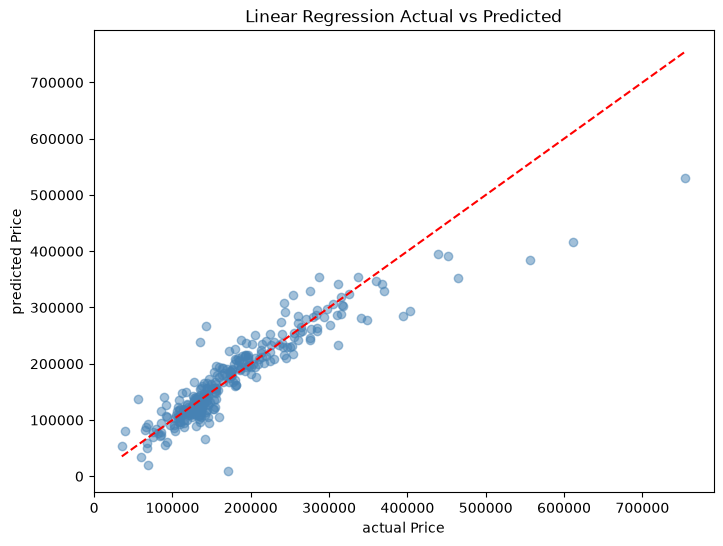

In [19]:
#iniatializing features and target to X AND y
X=train.drop('SalePrice', axis=1)              
y=train['SalePrice']

#scaling 
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

#linear regression model
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

lr= LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

#checking the performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

#ploting graph
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('actual Price')
plt.ylabel('predicted Price')
plt.title('Linear Regression Actual vs Predicted')
plt.show()

SalePrice
0    1302
1     150
2       8
Name: count, dtype: int64


C:\Users\MR.LEGEND\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MR.LEGEND\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MR.LEGEND\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\m

Accuracy: 0.952054794520548
Confusion Matrix:
 [[255   1   0]
 [ 10  23   0]
 [  0   3   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       256
           1       0.85      0.70      0.77        33
           2       0.00      0.00      0.00         3

    accuracy                           0.95       292
   macro avg       0.60      0.56      0.58       292
weighted avg       0.94      0.95      0.94       292



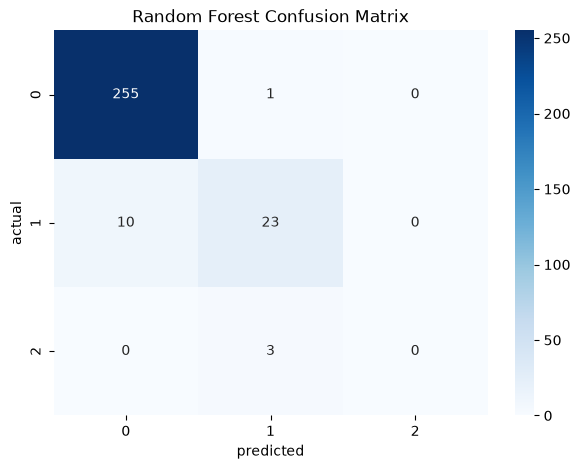

In [20]:
price_min = train['SalePrice'].min()
price_max = train['SalePrice'].max()
low_thresh = price_min + (price_max - price_min) / 3
high_thresh = price_min + 2 * (price_max - price_min) / 3
def categorize(price):
    if price <= low_thresh:
        return 0
    elif price <= high_thresh:
        return 1
    else:
        return 2

#initializing features and target to X_cat AND y_cat
y_cat = train['SalePrice'].apply(categorize)
X_cat = train.drop('SalePrice', axis=1)
print(y_cat.value_counts())

#Random Forest Classifier
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_scaled, y_cat, test_size=0.2, random_state=42)

rf=RandomForestClassifier()
rf.fit(X_train_c, y_train_c)

y_pred_rf = rf.predict(X_test_c)

#checking the performance
a = accuracy_score(y_test_c, y_pred_rf)
cm = confusion_matrix(y_test_c, y_pred_rf)
cr = classification_report(y_test_c, y_pred_rf)

print("Accuracy:", a)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", cr)

#ploting graph
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test_c, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Random Forest Confusion Matrix')
plt.show()


C:\Users\MR.LEGEND\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MR.LEGEND\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MR.LEGEND\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\m

Accuracy: 0.9486301369863014
Confusion Matrix:
 [[253   3   0]
 [  9  24   0]
 [  1   2   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       256
           1       0.83      0.73      0.77        33
           2       0.00      0.00      0.00         3

    accuracy                           0.95       292
   macro avg       0.60      0.57      0.58       292
weighted avg       0.94      0.95      0.94       292



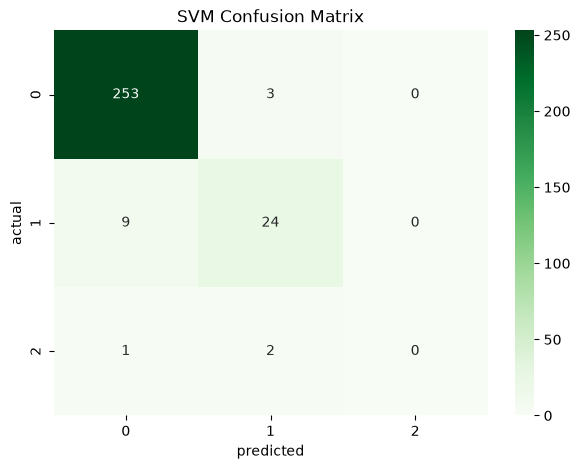

In [21]:
#SVM Classifier
svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_train_c, y_train_c)

y_pred_svc = svc.predict(X_test_c)

#checking the performance
a = accuracy_score(y_test_c, y_pred_svc)
cm = confusion_matrix(y_test_c, y_pred_svc)
cr = classification_report(y_test_c, y_pred_svc)
print("Accuracy:", a)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", cr)

#ploting graph
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test_c, y_pred_svc), annot=True, fmt='d', cmap='Greens')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('SVM Confusion Matrix')
plt.show()